## Mini Project 1 - Students' Performance

##### Retrieve data from kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\jayde\.cache\kagglehub\datasets\spscientist\students-performance-in-exams\versions\1


##### Import relevant libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Kaggle dataset for student performance and clean the data

In [4]:
# Load CSV into DataFrame

df = pd.read_csv("C:/Users/jayde/.cache/kagglehub/datasets/spscientist/students-performance-in-exams/versions/1/StudentsPerformance.csv")

#### View data

In [19]:
# View dataframe
df.shape, df.columns, df.head()

((1000, 14),
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course', 'math score', 'reading score',
        'writing score', 'total score', 'average', 'gender_encoded',
        'lunch_encoded', 'test_prep_encoded', 'parent_edu_encoded'],
       dtype='object'),
    gender race/ethnicity parental level of education         lunch  \
 0  female        group B           bachelor's degree      standard   
 1  female        group C                some college      standard   
 2  female        group B             master's degree      standard   
 3    male        group A          associate's degree  free/reduced   
 4    male        group C                some college      standard   
 
   test preparation course  math score  reading score  writing score  \
 0                    none          72             72             74   
 1               completed          69             90             88   
 2                    none          90 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


#### Check for missing values

In [7]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
# Check for duplicated data
duplicates = df.duplicated()

# Print how many duplicates exist
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


#### Create column called 'average'

In [9]:
# Calculate total score
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
# Calculate average score
df['average'] = df['total score'] / 3
# View data
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### Visualise data

#### Performance by Gender

<Figure size 1000x500 with 0 Axes>

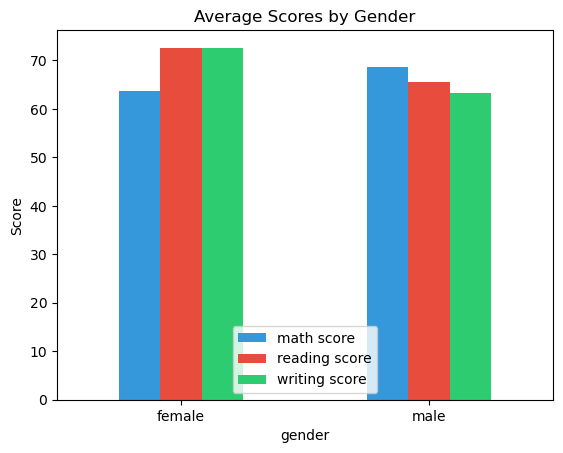

In [23]:
# Calculate average scores by gender
gender_avg = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

# Plot
plt.figure(figsize=(10, 5))
gender_avg.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Average Scores by Gender')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

#### Race/Ethnicity and Performace

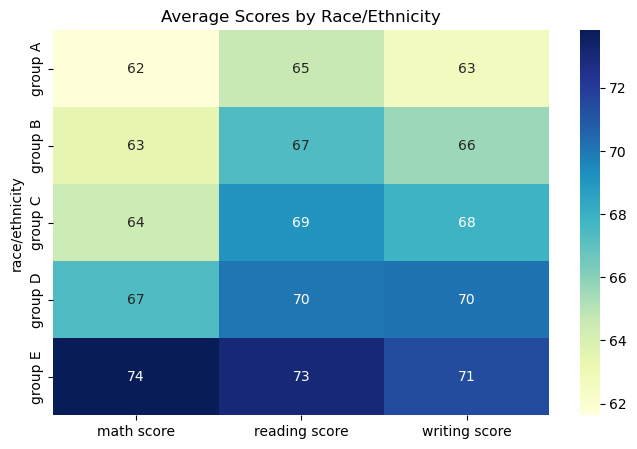

In [25]:
# Group by race and compute mean scores
race_avg = df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(race_avg, annot=True, cmap='YlGnBu')
plt.title('Average Scores by Race/Ethnicity')
plt.show()

#### Impact of Lunch

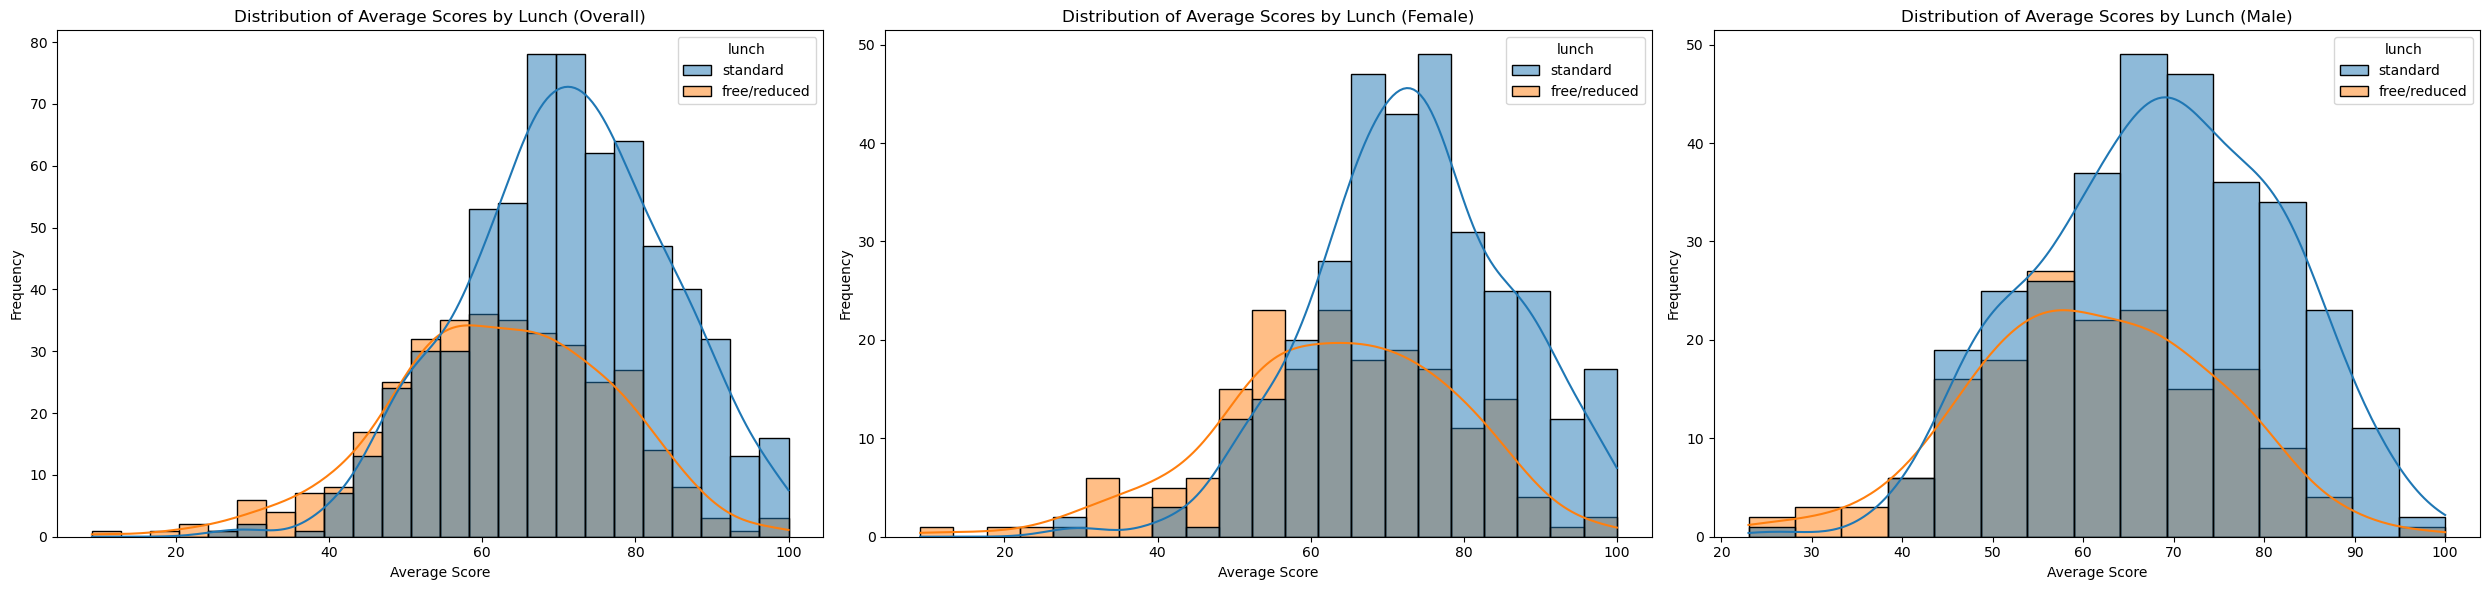

In [12]:
# Create a subplot with three histograms side by side
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

# Plot the first histogram (Overall)
sns.histplot(data=df, x='average', kde=True, hue='lunch', ax=axs[0])
axs[0].set_title('Distribution of Average Scores by Lunch (Overall)')
axs[0].set_xlabel('Average Score')
axs[0].set_ylabel('Frequency')

# Plot the second histogram (Female)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='lunch', ax=axs[1])
axs[1].set_title('Distribution of Average Scores by Lunch (Female)')
axs[1].set_xlabel('Average Score')
axs[1].set_ylabel('Frequency')

# Plot the third histogram (Male)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch', hue_order = ['standard', 'free/reduced'], ax=axs[2])
axs[2].set_title('Distribution of Average Scores by Lunch (Male)')
axs[2].set_xlabel('Average Score')
axs[2].set_ylabel('Frequency')

# Display the subplots
plt.tight_layout()
plt.show()


#### Impact of Parental education

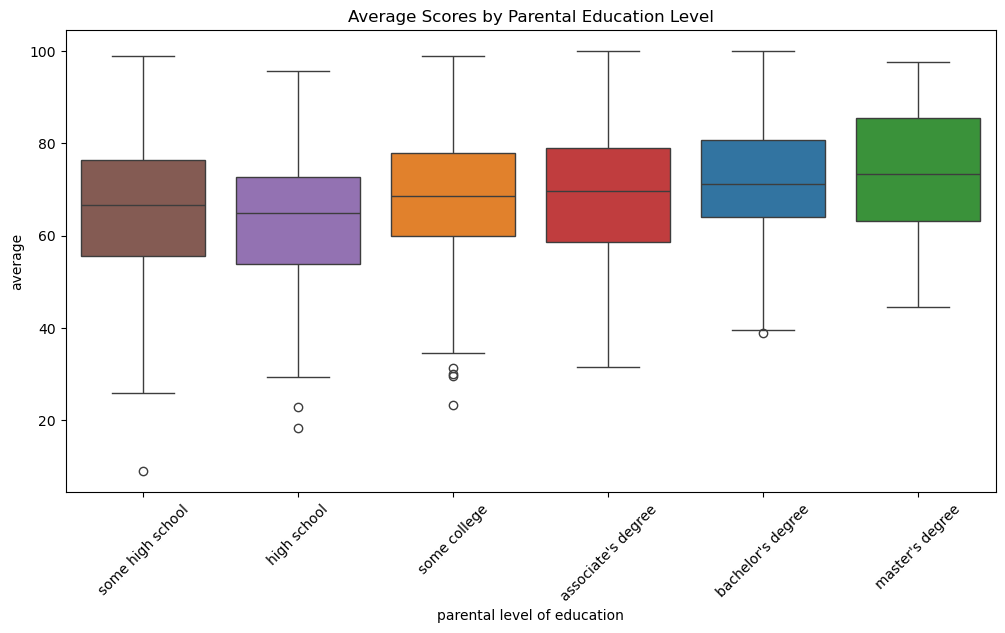

In [13]:
# Order education levels logically
edu_order = [
    'some high school', 'high school', 'some college',
    "associate's degree", "bachelor's degree", "master's degree"
]

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='parental level of education',
    y='average',
    data=df,
    order=edu_order,
    hue='parental level of education',
    legend=False
)
plt.title('Average Scores by Parental Education Level')
plt.xticks(rotation=45)
plt.show()

#### Impact of Test preparation course

<Figure size 1000x500 with 0 Axes>

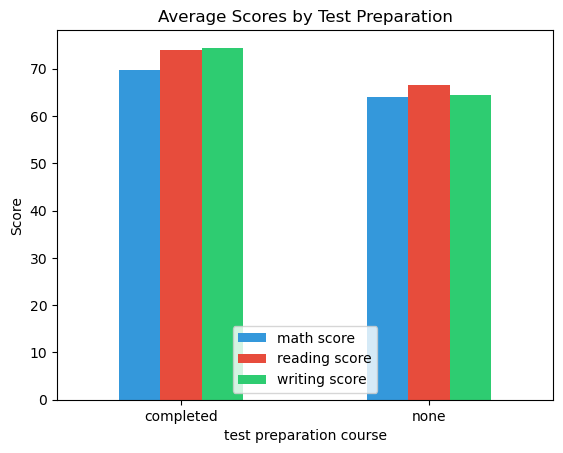

In [14]:
# Compare scores with/without test prep
prep_avg = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

# Plot
plt.figure(figsize=(10, 5))
prep_avg.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Average Scores by Test Preparation')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

#### Correlation Matrix

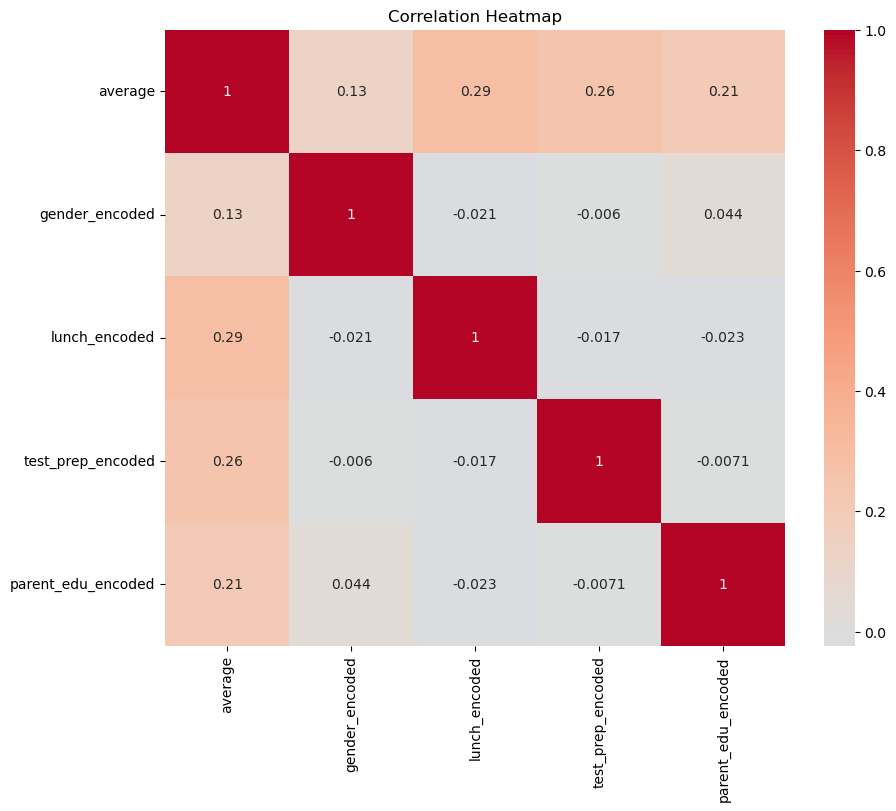

In [15]:
# Binary encoding (0/1)
df['gender_encoded'] = df['gender'].map({'male': 0, 'female': 1})
df['lunch_encoded'] = df['lunch'].map({'free/reduced': 0, 'standard': 1})
df['test_prep_encoded'] = df['test preparation course'].map({'none': 0, 'completed': 1})

# Ordinal encoding (1-6 for education)
education_order = {
    'some high school': 1,
    'high school': 2,
    'some college': 3,
    "associate's degree": 4,
    "bachelor's degree": 5,
    "master's degree": 6
}
df['parent_edu_encoded'] = df['parental level of education'].map(education_order)

df_corrmat = df[["average", "gender_encoded", "lunch_encoded", "test_prep_encoded", "parent_edu_encoded"]]
# Compute correlation
corr = df_corrmat.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

##### Compare averages of lunch type

In [17]:
lunch_comparison = df.groupby('lunch')['average'].mean()
print(lunch_comparison)

lunch
free/reduced    62.199061
standard        70.837209
Name: average, dtype: float64
